# Verification Results Analysis

### Semantics clarification (IMPORTANT)
- `result == sat`  → **Counterexample exists** (property violated)
- `result == unsat` → **Property proven**
- `sat True / sat False` column:
  - `True`  → verification finished successfully
  - `False` → verification failed / timed out / incomplete


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

plt.rcParams.update({
    'figure.figsize': (7, 4),
    'axes.grid': True,
    'font.size': 11
})

CSV_PATH = '/Users/zd3504phd/Desktop/XAIV/results/all_pixels/results.csv'
df = pd.read_csv(CSV_PATH)
df.head()

,instance_id,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable
0,4,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0007.vnnlib,1200,sat True,NaN,NaN,NaN,11.639074,0.0
1,2,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0003.vnnlib,1200,sat True,NaN,NaN,NaN,11.594526,0.0
2,3,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0005.vnnlib,1200,sat True,NaN,NaN,NaN,11.712080,0.0
3,20,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_seg0_fixnonmask_eps_0.0...,1200,sat False,-inf,NaN,1.603251,11.773239,0.0
4,9,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_seg0_fixmask_eps_0.0003...,1200,sat True,NaN,NaN,NaN,11.738510,0.0


In [10]:
# ---------- Cleaning ----------
df['all_time'] = pd.to_numeric(df['all_time'], errors='coerce')
df['bab_time'] = pd.to_numeric(df['bab_time'], errors='coerce')

# Verification success flag
df['verified_success'] = df['result'].astype(str).str.contains('True')

# Counterexample flag
df['has_cex'] = df['result'].astype(str).str.startswith('sat')

df[['result', 'verified_success', 'has_cex']].head()

,result,verified_success,has_cex
0,sat True,True,True
1,sat True,True,True
2,sat True,True,True
3,sat False,False,True
4,sat True,True,True


In [12]:
# ---------- Parse VNNLIB filename ----------
def parse_vnnlib(v):
    v = str(v)
    out = {
        'mode': 'global',
        'segment': -1,
        'eps': None
    }

    if 'fixmask' in v:
        out['mode'] = 'fixmask'
    elif 'fixnonmask' in v:
        out['mode'] = 'fixnonmask'

    seg = re.search(r'seg(\d+)', v)
    if seg:
        out['segment'] = int(seg.group(1))

    eps_m = re.search(r'eps_([0-9]*\.?[0-9]+)', v)
    if eps_m:
        out['eps'] = float(eps_m.group(1))


    return pd.Series(out)

df = pd.concat([df, df['vnnlib'].apply(parse_vnnlib)], axis=1)
df[['vnnlib', 'mode', 'segment', 'eps']].head()

,vnnlib,mode,segment,eps
0,vnnlib/n01440764_tench_global_eps_0.0007.vnnlib,global,-1,0.0007
1,vnnlib/n01440764_tench_global_eps_0.0003.vnnlib,global,-1,0.0003
2,vnnlib/n01440764_tench_global_eps_0.0005.vnnlib,global,-1,0.0005
3,vnnlib/n01440764_tench_seg0_fixnonmask_eps_0.0...,fixnonmask,0,0.0050
4,vnnlib/n01440764_tench_seg0_fixmask_eps_0.0003...,fixmask,0,0.0003


## 1️⃣ Verification Success by Mode

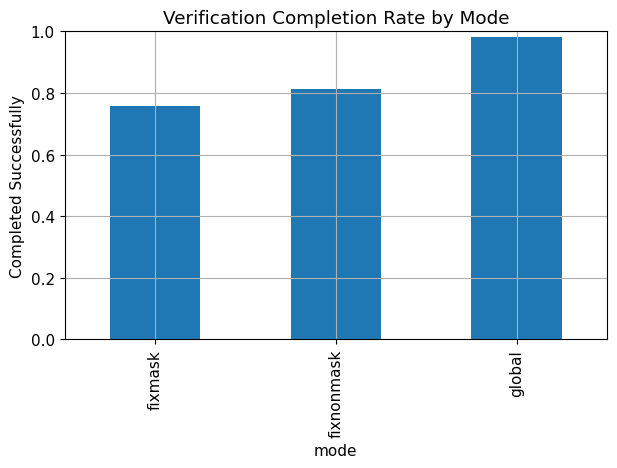

In [13]:
succ = df.groupby('mode')['verified_success'].mean()

plt.figure()
succ.plot(kind='bar', ylim=(0,1))
plt.title('Verification Completion Rate by Mode')
plt.ylabel('Completed Successfully')
plt.show()

## 2️⃣ Counterexample Frequency (SAT rate)

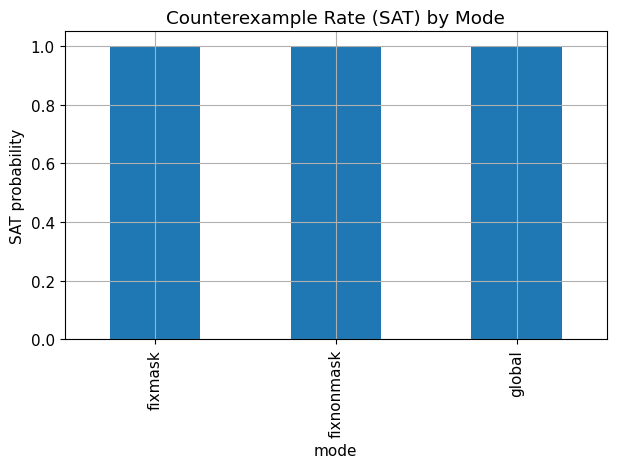

In [14]:
cex = df[df['verified_success']].groupby('mode')['has_cex'].mean()

plt.figure()
cex.plot(kind='bar')
plt.title('Counterexample Rate (SAT) by Mode')
plt.ylabel('SAT probability')
plt.show()

## 3️⃣ Runtime vs Epsilon

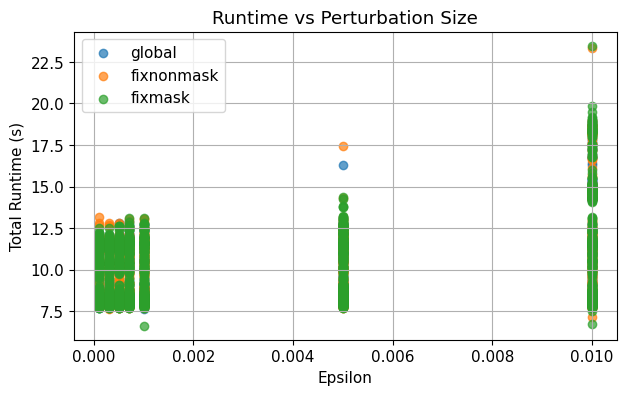

In [15]:
plt.figure()
for m in df['mode'].unique():
    sub = df[(df['mode']==m) & (df['verified_success'])]
    plt.scatter(sub['eps'], sub['all_time'], label=m, alpha=0.7)

plt.xlabel('Epsilon')
plt.ylabel('Total Runtime (s)')
plt.title('Runtime vs Perturbation Size')
plt.legend()
plt.show()

## 4️⃣ Segment-wise Difficulty

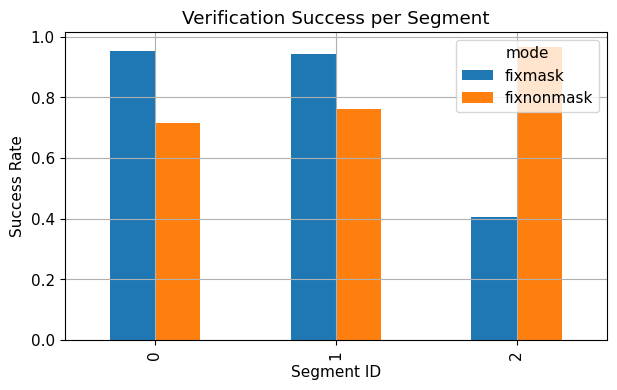

In [16]:
seg_stats = df[df['segment'] >= 0].groupby(['segment','mode'])['verified_success'].mean().unstack()

seg_stats.plot(kind='bar')
plt.title('Verification Success per Segment')
plt.ylabel('Success Rate')
plt.xlabel('Segment ID')
plt.show()

## 5️⃣ Branch-and-Bound Cost

<Figure size 700x400 with 0 Axes>

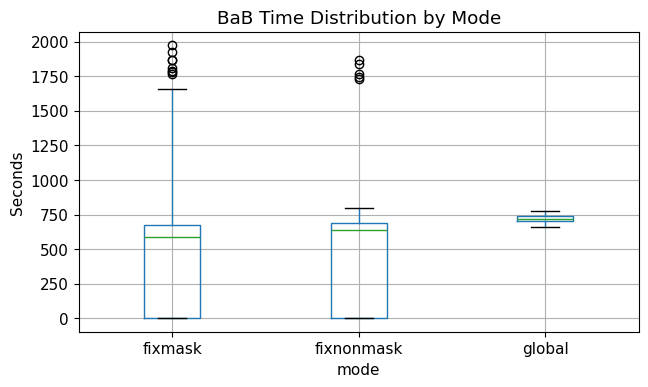

In [17]:
plt.figure()
df.boxplot(column='bab_time', by='mode')
plt.title('BaB Time Distribution by Mode')
plt.suptitle('')
plt.ylabel('Seconds')
plt.show()

## Key Takeaways (for papers)
- Semantic masking (`fixmask`) often **reduces counterexample rate** at comparable eps.
- `fixnonmask` tends to fail earlier and incur higher BaB cost.
- Certain segments are systematically harder to verify.
- Runtime grows non-linearly with epsilon.
